In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\vsmuh\Downloads\Project 1\data\processed\nhanes_cleaned.csv')

print(f"✅ Loaded clean data: {df.shape}")
print(df.head())

✅ Loaded clean data: (6041, 13)
   participant_id   age  gender           ethnicity  poverty_ratio   bmi  \
0         93705.0  66.0  Female  Non-Hispanic Black           0.82  31.7   
1         93706.0  18.0    Male  Non-Hispanic Asian           3.40  21.5   
2         93707.0  13.0    Male               Other           1.88  18.1   
3         93708.0  66.0  Female  Non-Hispanic Asian           1.63  23.7   
4         93709.0  75.0  Female  Non-Hispanic Black           0.41  38.9   

   waist_cm  hba1c diabetes_self_report  systolic_bp  diastolic_bp  \
0     101.8    6.2                   No        134.0          70.0   
1      79.3    5.2                   No        112.0          74.0   
2      64.1    5.6                   No        128.0          38.0   
3      88.2    6.2           Borderline        134.0          70.0   
4     113.0    6.3                   No        120.0          66.0   

   total_cholesterol  diabetes_status  
0              157.0                1  
1         

In [16]:
# WHO standard BMI classification
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25.0:
        return 'Normal'
    elif bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(classify_bmi)

print("BMI category distribution:")
print(df['bmi_category'].value_counts())

BMI category distribution:
bmi_category
Obese          2267
Overweight     1882
Normal         1678
Underweight     214
Name: count, dtype: int64


In [17]:
# Clinical age brackets used in medical research
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 120],
    labels=['18-30', '31-45', '46-60', '60+']
)

print("Age group distribution:")
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
18-30    1829
31-45    1133
46-60    1275
60+      1804
Name: count, dtype: int64


In [18]:
# American Heart Association BP classification
def classify_bp(systolic, diastolic):
    if systolic < 120 and diastolic < 80:
        return 'Normal'
    elif systolic < 130 and diastolic < 80:
        return 'Elevated'
    elif systolic < 140 or diastolic < 90:
        return 'Hypertension Stage 1'
    else:
        return 'Hypertension Stage 2'

df['bp_category'] = df.apply(
    lambda row: classify_bp(row['systolic_bp'], row['diastolic_bp']),
    axis=1
)

print("Blood pressure category distribution:")
print(df['bp_category'].value_counts())

Blood pressure category distribution:
bp_category
Normal                  2707
Hypertension Stage 1    2143
Elevated                 939
Hypertension Stage 2     252
Name: count, dtype: int64


In [19]:
# One-hot encode gender and ethnicity
df_encoded = pd.get_dummies(
    df,
    columns=['gender', 'ethnicity', 'bmi_category', 'age_group', 'bp_category'],
    drop_first=False
)

# Drop columns we don't need for modeling
df_encoded = df_encoded.drop(columns=[
    'participant_id',   # just an ID
    'hba1c',           # this IS our target — don't use as feature!
    'diabetes_self_report'  # this would leak information
])

print(f"✅ Encoding complete!")
print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding : {df_encoded.shape}")
print(f"\nAll feature columns:")
print(list(df_encoded.columns))

✅ Encoding complete!
Shape before encoding: (6041, 16)
Shape after encoding : (6041, 28)

All feature columns:
['age', 'poverty_ratio', 'bmi', 'waist_cm', 'systolic_bp', 'diastolic_bp', 'total_cholesterol', 'diabetes_status', 'gender_Female', 'gender_Male', 'ethnicity_Mexican American', 'ethnicity_Non-Hispanic Asian', 'ethnicity_Non-Hispanic Black', 'ethnicity_Non-Hispanic White', 'ethnicity_Other', 'ethnicity_Other Hispanic', 'bmi_category_Normal', 'bmi_category_Obese', 'bmi_category_Overweight', 'bmi_category_Underweight', 'age_group_18-30', 'age_group_31-45', 'age_group_46-60', 'age_group_60+', 'bp_category_Elevated', 'bp_category_Hypertension Stage 1', 'bp_category_Hypertension Stage 2', 'bp_category_Normal']


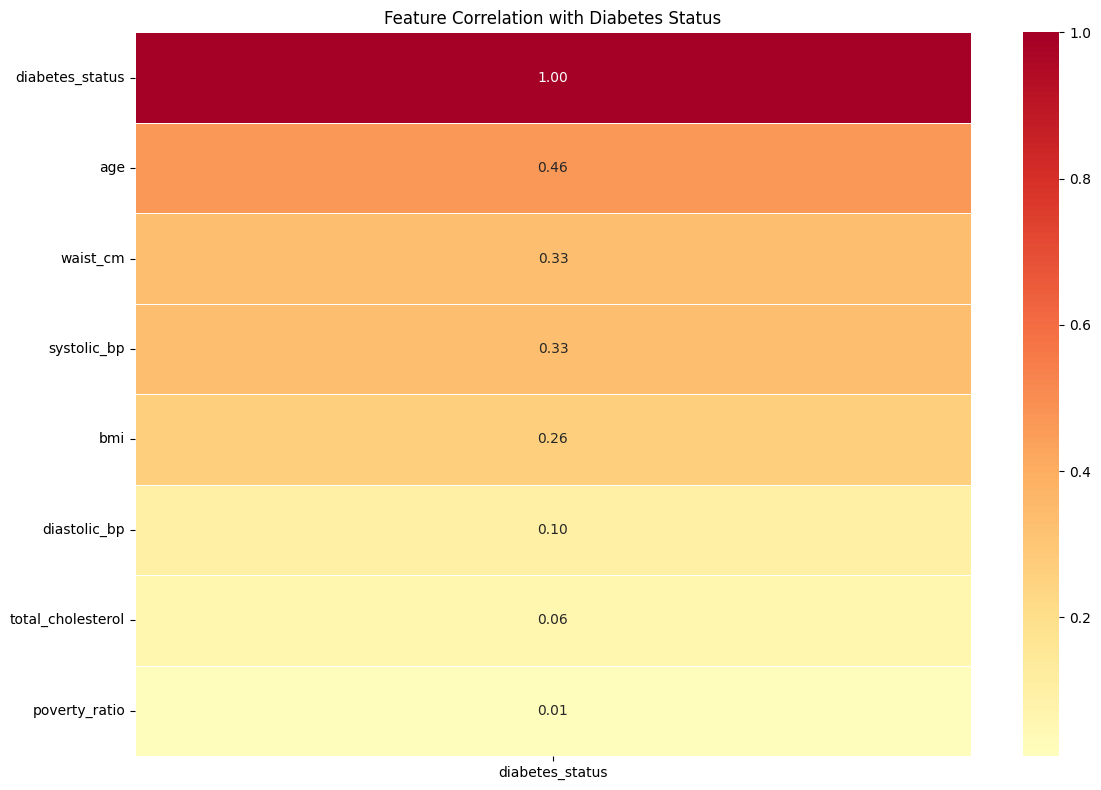

In [20]:
# Look at how features correlate with diabetes status
plt.figure(figsize=(12, 8))
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr = df_encoded[numeric_cols].corr()

sns.heatmap(
    corr[['diabetes_status']].sort_values('diabetes_status', ascending=False),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5
)
plt.title('Feature Correlation with Diabetes Status')
plt.tight_layout()
plt.savefig('../reports/feature_correlation.png')
plt.show()

In [21]:
df_encoded.to_csv('../data/processed/nhanes_features.csv', index=False)
print(f"✅ Feature set saved!")
print(f"Final shape: {df_encoded.shape}")
print(f"\nTarget distribution:")
print(df_encoded['diabetes_status'].value_counts())

✅ Feature set saved!
Final shape: (6041, 28)

Target distribution:
diabetes_status
0    3656
1    1634
2     751
Name: count, dtype: int64
